11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Feature matrix (x_train): (60000, 28, 28)
Target matrix (y_train): (60000,)
Feature matrix (x_test): (10000, 28, 28)
Target matrix (y_test): (10000,)


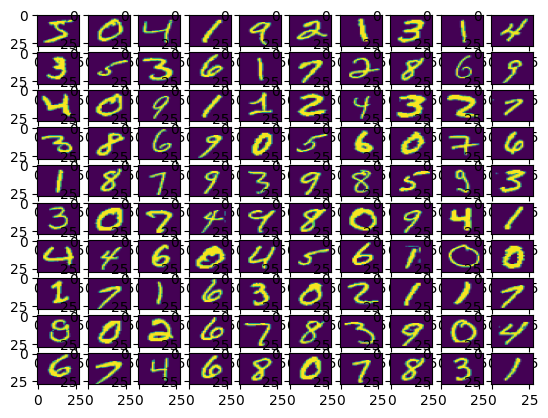

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.2900 - loss: 2.2020 - val_accuracy: 0.7268 - val_loss: 1.6877
Epoch 2/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - accuracy: 0.7302 - loss: 1.5112 - val_accuracy: 0.8176 - val_loss: 0.9938
Epoch 3/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.8150 - loss: 0.9125 - val_accuracy: 0.8664 - val_loss: 0.6480
Epoch 4/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.8613 - loss: 0.6221 - val_accuracy: 0.8888 - val_loss: 0.4848
Epoch 5/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.8850 - loss: 0.4800 - val_accuracy: 0.9026 - val_loss: 0.3982
Epoch 6/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.8998 - loss: 0.4011 - val_accuracy: 0.9091 - val_loss: 0.3481
Epoch 7/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.9047 - loss: 0.3577 - val_accuracy: 0.9150 - val_loss: 0.3164
Epoch 8/10
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.9130 - loss: 0.3246 - val_accuracy: 0.9199 - v

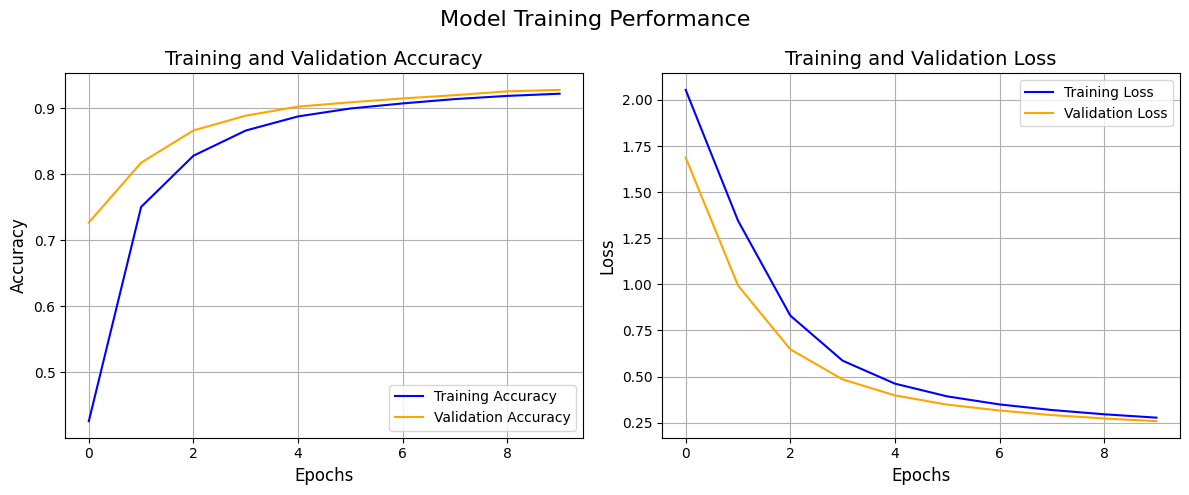

In [1]:
#Implementing Multi Layer Perceptron (MLP) using TensorFlow
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

gray_scale = 255

x_train = x_train.astype('float32') / gray_scale
x_test = x_test.astype('float32') / gray_scale

print("Feature matrix (x_train):", x_train.shape)
print("Target matrix (y_train):", y_train.shape)
print("Feature matrix (x_test):", x_test.shape)
print("Target matrix (y_test):", y_test.shape)

fig, ax = plt.subplots(10, 10)
k = 0
for i in range(10):
    for j in range(10):
        ax[i][j].imshow(x_train[k].reshape(28, 28), aspect='auto')
        k += 1
plt.show()

model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(256, activation='sigmoid'),
    Dense(128, activation='sigmoid'),
    Dense(10, activation='softmax'),
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

mod = model.fit(x_train, y_train, epochs=10,
          batch_size=2000,
          validation_split=0.2)

print(mod)
results = model.evaluate(x_test, y_test, verbose=0)
print('Test loss, Test accuracy:', results)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(mod.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(mod.history['val_accuracy'],
         label='Validation Accuracy', color='orange')
plt.title('Training and Validation Accuracy', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(mod.history['loss'], label='Training Loss', color='blue')
plt.plot(mod.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend()
plt.grid(True)

plt.suptitle("Model Training Performance", fontsize=16)
plt.tight_layout()
plt.show()